## Analise comparativa de tempo de execução em algorimos de ordenação : MergeSort e QuickSort em diferentes tamanhos de entrada.


## Análise assintótica


O Mergesort possui complexidade:

T(n) = O(n log n)

tanto no melhor, médio e pior caso.

O Quicksort apresenta:

- Melhor caso: O(n log n)
- Caso médio: O(n log n)
- Pior caso: O(n²)

Na implementação iterativa, a eliminação da recursão não altera,
por si só, a ordem de complexidade do algoritmo. A principal
diferença está na forma como a estrutura necessária para controlar
as subdivisões é administrada.

Experimentalmente, espera-se observar um crescimento aproximadamente
compatível com n log n para o comportamento médio dos dois algoritmos.


## Implementação e análise experimental (*benchmarking*)

In [ ]:

import random
import time
import matplotlib.pyplot as plt
import pandas as pd
import statistics

## QuickSort

In [ ]:
def quicksort_iterativo(a):
    pilha = [(0, len(a) - 1)]

    while pilha:
        inicio, fim = pilha.pop()

        if inicio >= fim:
            continue

        pivo = a[fim]
        i = inicio - 1

        for j in range(inicio, fim):
            if a[j] <= pivo:
                i += 1
                a[i], a[j] = a[j], a[i]

        i += 1
        a[i], a[fim] = a[fim], a[i]

        # Subvetor esquerdo
        if inicio < i - 1:
            pilha.append((inicio, i - 1))

        # Subvetor direito
        if i + 1 < fim:
            pilha.append((i + 1, fim))

    return a

## MergeSort

In [ ]:
def mergesort(a):
    if len(a) <= 1:
        return a

    meio = len(a) // 2

    esquerda = mergesort(a[:meio])
    direita = mergesort(a[meio:])

    return merge(esquerda, direita)


def merge(esquerda, direita):
    resultado = []

    i = 0
    j = 0

    while i < len(esquerda) and j < len(direita):

        if esquerda[i] <= direita[j]:
            resultado.append(esquerda[i])
            i += 1
        else:
            resultado.append(direita[j])
            j += 1

    resultado.extend(esquerda[i:])
    resultado.extend(direita[j:])

    return resultado

In [ ]:
tamanhos = [
    1000,
    2000,
    5000,
    10000,
    20000,
    50000,
    100000
]

# gerar vetores aleatorios
def gerar_vetor(tamanho):
    return [random.randint(0, 1_000_000) for _ in range(tamanho)]



# funcao pra medir o tempo de execucao
def medir_tempo(algoritmo, dados):
    inicio = time.perf_counter()

    algoritmo(dados)

    fim = time.perf_counter()

    return fim - inicio

# função para medir o desvio padrão e a média
def medir_desvio_padrao(algoritmo, dados, repeticoes=30):
    tempos = []

    for _ in range(repeticoes):
        copia = dados.copy()  # evita ordenar um vetor já ordenado
        tempos.append(medir_tempo(algoritmo, copia))

    media = statistics.mean(tempos)
    desvio = statistics.stdev(tempos)  # desvio padrão amostral

    return media, desvio

In [ ]:
resultados = []

repeticoes = 5

for n in tamanhos:

    tempos_quick = []
    tempos_merge = []

    for _ in range(repeticoes):

        dados = gerar_vetor(n)

        tempos_quick.append(
            medir_tempo(quicksort_iterativo, dados.copy())
        )

        tempos_merge.append(
            medir_tempo(mergesort, dados.copy())
        )

    resultados.append({
        "n": n,
        "Quicksort": statistics.mean(tempos_quick),
        "DP_Quicksort": statistics.stdev(tempos_quick),
        "Mergesort": statistics.mean(tempos_merge),
        "DP_Mergesort": statistics.stdev(tempos_merge)
    })
# DP= Desvio padrao



In [ ]:
df = pd.DataFrame(resultados)

df

,n,Quicksort,DP_Quicksort,Mergesort,DP_Mergesort
0,1000,0.002329,0.000186,0.003972,0.000027
1,2000,0.004848,0.000174,0.008100,0.000418
2,5000,0.013728,0.000332,0.024189,0.001039
3,10000,0.030712,0.001685,0.051967,0.002352
4,20000,0.069669,0.000939,0.113943,0.004179
5,50000,0.134829,0.043808,0.199879,0.058309
6,100000,0.244481,0.015012,0.374837,0.011123


###  Projeto do teste de desempenho

> *TLDR; aqui você vai descrever como as entradas foram geradas e as condições do experimento*


(1) Geração de entrada:

Foram utilizadas entradas de diferentes tamanhos, permitindo analisar o comportamento dos algoritmos conforme o número de elementos aumenta. Para cada tamanho, foram gerados vetores contendo números inteiros.

foram consideradas três configurações de entrada: aleatória, ordenada crescentemente e ordenada decrescentemente. Essas configurações permitem observar tanto situações próximas ao comportamento médio quanto situações que podem provocar comportamentos desfavoráveis, especialmente no Quicksort, dependendo da estratégia de escolha do pivô.

Para o Quicksort iterativo, foi utilizada a estratégia de selecionar o último elemento como pivô. Dessa forma, entradas já ordenadas, tanto crescentemente quanto decrescentemente, provocam a divisão mais desbalanceada possível dos subproblemas, levando ao pior caso teórico de complexidade O(n²).
<br>
(2)Ambiente de Execucao: <br>
Versão do interpretador:Python 3.11
Ambiente de desenvolvimento:Google Colab.

 O tempo de execução foi medido utilizando um temporizador de alta resolução disponível na biblioteca padrão do Python.<br>
 RAM do sistema
1.2 / 12.7 GB

Disco
20.3 / 107.7 GB

Para cada combinação entre tamanho e tipo de entrada, cada algoritmo foi executado 20 vezes.

tempo de execução foi medido utilizando a biblioteca` time` padrão do Python. e tambem a biblioteca` statistics `para medir o Desvio Padrao.




## Resultados e discussão

O Mergesort apresentou crescimento mais acentuado nos dados obtidos, embora sua complexidade permaneça \(O(n\log n)\) para diferentes configurações de entrada. A diferença observada entre os algoritmos não significa que sua complexidade assintótica tenha sido alterada. Ela pode estar relacionada aos custos constantes das implementações e à forma como cada algoritmo manipula os dados.

###  Tabelas de dados brutos


### Quicksort

| Tamanho da Entrada (n) | Tempo Médio de Execução (ms) | Desvio Padrão (ms) |
|:-----------------------:|:----------------------------:|:------------------:|
| 1000   | 0.002329 | 0.000186 |
| 2000   | 0.004848 | 0.000174 |
| 5000   | 0.013728 | 0.000332 |
| 10000  | 0.030712 | 0.001685 |
| 20000  | 0.069669 | 0.000939 |
| 50000  | 0.134829 | 0.043808 |
| 100000 | 0.244481 | 0.015012 |

### Mergesort

| Tamanho da Entrada (n) | Tempo Médio de Execução (ms) | Desvio Padrão (ms) |
|:-----------------------:|:----------------------------:|:------------------:|
| 1000   | 0.003972 | 0.000027 |
| 2000   | 0.008100 | 0.000418 |
| 5000   | 0.024189 | 0.001039 |
| 10000  | 0.051967 | 0.002352 |
| 20000  | 0.113943 | 0.004179 |
| 50000  | 0.199879 | 0.058309 |
| 100000 | 0.374837 | 0.011123 |


###  Representação gráfica (extra)

Grafico de linha , mostrando o crescimento do tempo de execução em função do tamanho da entrada.

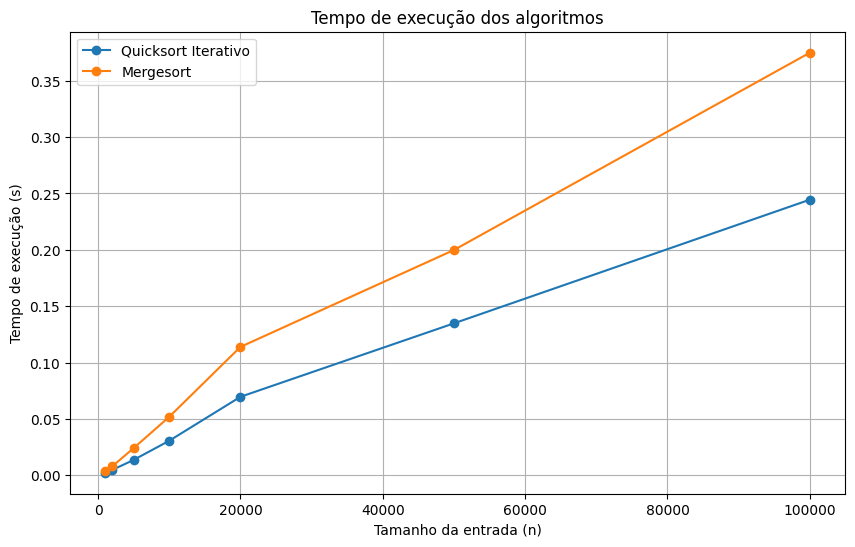

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(df["n"], df["Quicksort"], marker="o", label="Quicksort Iterativo")
plt.plot(df["n"], df["Mergesort"], marker="o", label="Mergesort")

plt.xlabel("Tamanho da entrada (n)")
plt.ylabel("Tempo de execução (s)")
plt.title("Tempo de execução dos algoritmos")
plt.legend()
plt.grid()

plt.show()

Observa-se que o tempo de execução dos dois algoritmos aumenta conforme o tamanho da entrada cresce. O Quicksort iterativo apresentou menor tempo de execução em todos os tamanhos analisados, enquanto o Mergesort apresentou crescimento mais acentuado, chegando a aproximadamente 0,37 s para 100.000 elementos, contra aproximadamente 0,24 s do Quicksort.


###  Análise e interpretação


Os resultados experimentais mostram que o tempo de execução dos dois algoritmos aumenta à medida que o tamanho da entrada cresce, conforme o esperado.

A estrutura das entradas projetadas para o pior caso foi particularmente relevante para o Quicksort, pois provocou divisões desbalanceadas e permitiu avaliar experimentalmente uma situação próxima ao seu pior comportamento teórico.

Apesar disso, o gráfico não apresenta uma curva parabólica claramente definida. Isso pode ocorrer devido ao tamanho limitado das entradas, aos custos constantes da implementação, às características do interpretador Python e às variações do ambiente de execução.
